In [2]:
import pandas as pd
import duckdb

conn = duckdb.connect("../data/exoplanets.db")
df = conn.execute("SELECT * FROM exoplanets").df()
conn.close()

print(f"Filas: {len(df)}")
print(f"Columnas: {list(df.columns)}")
df.head()

Filas: 6147
Columnas: ['pl_name', 'hostname', 'pl_masse', 'pl_rade', 'pl_orbper', 'pl_eqt', 'st_teff', 'discoverymethod', 'disc_year']


,pl_name,hostname,pl_masse,pl_rade,pl_orbper,pl_eqt,st_teff,discoverymethod,disc_year
0,HD 114783 b,HD 114783,NaN,NaN,493.700000,NaN,5135.0,Radial Velocity,2001.0
1,HD 12661 c,HD 12661,NaN,NaN,1708.000000,NaN,5748.0,Radial Velocity,2002.0
2,HD 27894 c,HD 27894,NaN,NaN,36.070000,NaN,NaN,Radial Velocity,2017.0
3,TOI-4010 b,TOI-4010,11.0,3.02,1.348335,1441.0,4960.0,Transit,2023.0
4,HD 12661 b,HD 12661,NaN,NaN,262.708620,NaN,5645.0,Radial Velocity,2000.0


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6147 entries, 0 to 6146
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pl_name          6147 non-null   str    
 1   hostname         6147 non-null   str    
 2   pl_masse         2067 non-null   float64
 3   pl_rade          4565 non-null   float64
 4   pl_orbper        5802 non-null   float64
 5   pl_eqt           1694 non-null   float64
 6   st_teff          5413 non-null   float64
 7   discoverymethod  6147 non-null   str    
 8   disc_year        6146 non-null   float64
dtypes: float64(6), str(3)
memory usage: 611.4 KB


In [10]:
print("Porcentaje de datos faltantes por columna:")
print(round(df.isnull().mean() * 100, 1))

Porcentaje de datos faltantes por columna:
pl_name             0.0
hostname            0.0
pl_masse           66.4
pl_rade            25.7
pl_orbper           5.6
pl_eqt             72.4
st_teff            11.9
discoverymethod     0.0
disc_year           0.0
dtype: float64


In [13]:
df.isnull()

,pl_name,hostname,pl_masse,pl_rade,pl_orbper,pl_eqt,st_teff,discoverymethod,disc_year
0,False,False,True,True,False,True,False,False,False
1,False,False,True,True,False,True,False,False,False
2,False,False,True,True,False,True,True,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,True,True,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...
6142,False,False,False,True,False,True,True,False,False
6143,False,False,False,False,False,False,False,False,False
6144,False,False,False,True,False,True,False,False,False
6145,False,False,False,True,False,True,False,False,False


In [22]:
print("Estadística descriptiva:")
df.describe()

Estadística descriptiva:


,pl_masse,pl_rade,pl_orbper,pl_eqt,st_teff,disc_year
count,2067.000000,4565.000000,5.802000e+03,1694.000000,5413.000000,6146.000000
mean,821.784191,4.455934,4.470881e+03,1002.084002,5383.460660,2016.981939
std,1632.006826,4.959250,1.633350e+05,541.435953,1488.033733,4.962135
min,0.020000,0.309800,9.070629e-02,50.000000,415.000000,1992.000000
25%,11.540020,1.620000,4.353518e+00,578.250000,4909.000000,2014.000000
50%,162.093300,2.430000,1.113048e+01,903.000000,5545.000000,2016.000000
75%,683.650625,4.060000,3.971024e+01,1371.750000,5900.000000,2021.000000
max,9534.852210,87.205870,8.040000e+06,4050.000000,40000.000000,2026.000000


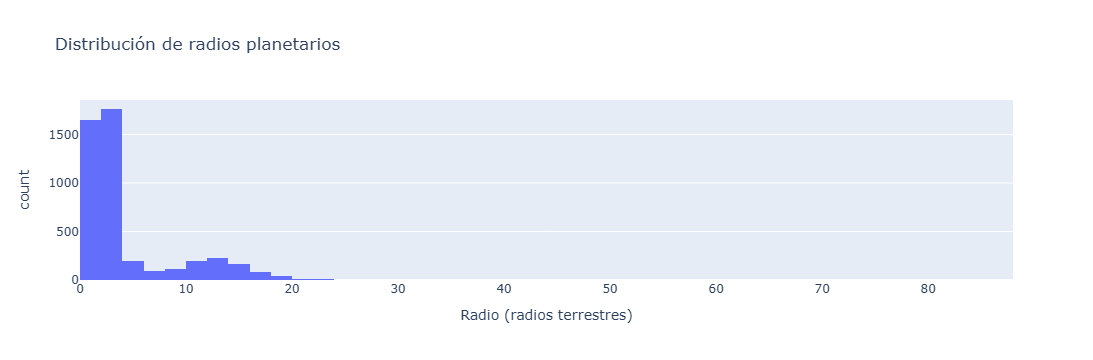

In [4]:
import plotly.express as px

fig = px.histogram(
    df.dropna(subset=['pl_rade']),
    x='pl_rade',
    nbins=50,
    title='Distribución de radios planetarios',
    labels={'pl_rade': 'Radio (radios terrestres)'}
)
fig.show()

In [5]:
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "browser"

fig = px.histogram(
    df.dropna(subset=['pl_rade']),
    x='pl_rade',
    nbins=50,
    title='Distribución de radios planetarios',
    labels={'pl_rade': 'Radio (radios terrestres)'}
)
fig.show()

In [6]:
metodos = df['discoverymethod'].value_counts().reset_index()
metodos.columns = ['discoverymethod', 'count']

fig = px.bar(
    metodos,
    x='discoverymethod',
    y='count',
    color='count',
    title='Exoplanetas por método de descubrimiento',
    labels={'discoverymethod': 'Método', 'count': 'Cantidad'}
)
fig.show()

In [36]:
descubrimientos = df.groupby('disc_year').size().reset_index()
descubrimientos.columns = ['año', 'cantidad']

fig = px.line(
    descubrimientos,
    x='año',
    y='cantidad',
    markers=True,
    title='Descubrimientos de exoplanetas por año',
    labels={'año': 'Año', 'cantidad': 'Planetas descubiertos'}
)
fig.show()

In [7]:
fig = px.scatter(
    df.dropna(subset=['pl_masse', 'pl_rade']),
    x='pl_masse',
    y='pl_rade',
    color='discoverymethod',
    hover_name='pl_name',
    log_x=True,
    title='Relación entre masa y radio de exoplanetas',
    labels={'pl_masse': 'Masa (masas terrestres)', 'pl_rade': 'Radio (radios terrestres)'}
)
fig.show()

In [40]:
correlacion = df[['pl_masse', 'pl_rade']].dropna().corr(method='pearson')
print("Correlación entre masa y radio:")
print(correlacion)

Correlación entre masa y radio:
          pl_masse   pl_rade
pl_masse  1.000000  0.365807
pl_rade   0.365807  1.000000


In [41]:
correlacion_spearman = df[['pl_masse', 'pl_rade']].dropna().corr(method='spearman')
print("Correlación Spearman entre masa y radio:")
print(correlacion_spearman)

Correlación Spearman entre masa y radio:
          pl_masse   pl_rade
pl_masse  1.000000  0.830838
pl_rade   0.830838  1.000000


In [8]:
zona_habitable = df[
    (df['pl_eqt'] >= 200) & 
    (df['pl_eqt'] <= 320) & 
    (df['pl_rade'] <= 1.5) &
    (df['pl_eqt'].notna()) &
    (df['pl_rade'].notna())
]

print(f"Planetas en zona habitable: {len(zona_habitable)}")
print(zona_habitable[['pl_name', 'pl_rade', 'pl_eqt', 'discoverymethod', 'disc_year']])

Planetas en zona habitable: 7
            pl_name  pl_rade  pl_eqt discoverymethod  disc_year
376      LP 890-9 c    1.367   272.0         Transit     2022.0
529          K2-3 d    1.458   305.2         Transit     2015.0
2409  Kepler-1649 c    1.060   234.0         Transit     2020.0
2879     TOI-2095 c    1.330   297.0         Transit     2023.0
3939  Kepler-1126 c    1.450   305.0         Transit     2023.0
5907  Kepler-1649 b    1.017   307.0         Transit     2017.0
6030    Kepler-62 f    1.410   208.0         Transit     2013.0


In [9]:
df['habitable'] = 'Otros planetas'
df.loc[zona_habitable.index, 'habitable'] = 'Zona habitable'

fig = px.scatter(
    df.dropna(subset=['pl_eqt', 'pl_rade']),
    x='pl_eqt',
    y='pl_rade',
    color='habitable',
    hover_name='pl_name',
    color_discrete_map={
        'Zona habitable': '#00ff87',
        'Otros planetas': '#aaaaaa'
    },
    title='Planetas en zona habitable vs resto',
    labels={'pl_eqt': 'Temperatura de equilibrio (K)', 'pl_rade': 'Radio (radios terrestres)'}
)
fig.show()

In [1]:
import duckdb
conn = duckdb.connect("../data/exoplanets.db")
duplicados = conn.execute("""
    SELECT nombre_planeta, COUNT(*) as total 
    FROM main.stg_exoplanets 
    GROUP BY nombre_planeta 
    HAVING COUNT(*) > 1 
    LIMIT 5
""").df()
conn.close()
print(duplicados)

Empty DataFrame
Columns: [nombre_planeta, total]
Index: []


In [3]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd
import duckdb
import plotly.express as px
import plotly.io as pio
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

pio.renderers.default = "browser"

conn = duckdb.connect("../data/exoplanets.db")
df = conn.execute("SELECT * FROM main.stg_exoplanets").df()
conn.close()

# Seleccionar columnas para clustering
columnas = ['radio_terrestre', 'temperatura_k', 'masa_terrestre', 'insolacion_tierra']
df_cluster = df[columnas].dropna()

print(f"Planetas con datos completos para clustering: {len(df_cluster)}")
df_cluster.describe()

Planetas con datos completos para clustering: 514


,radio_terrestre,temperatura_k,masa_terrestre,insolacion_tierra
count,514.000000,514.000000,514.000000,514.000000
mean,7.451576,1057.684825,263.061670,659.435729
std,5.861087,532.854016,699.812627,2209.018426
min,0.309800,163.000000,0.070000,0.181000
25%,2.172500,650.000000,6.822500,33.775000
50%,5.070000,943.600000,30.882585,139.500000
75%,12.492414,1437.000000,253.588939,729.000000
max,23.538859,4050.000000,8899.195396,44900.000000


In [6]:
scaler = StandardScaler()
datos_scaled = scaler.fit_transform(df_cluster)

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df_cluster['cluster'] = kmeans.fit_predict(datos_scaled)

print("Planetas por cluster:")
print(df_cluster['cluster'].value_counts().sort_index())

Planetas por cluster:
cluster
0    113
1    260
2      1
3    132
4      8
Name: count, dtype: int64


In [7]:
print("Características promedio por cluster:")
print(df_cluster.groupby('cluster').mean().round(2))

Características promedio por cluster:
         radio_terrestre  temperatura_k  masa_terrestre  insolacion_tierra
cluster                                                                   
0                  11.12         908.53          355.74             190.36
1                   2.41         773.70           21.60             157.34
2                  21.20        4050.00          915.35           44900.00
3                  13.84        1700.21          380.21            1593.07
4                  12.55        1418.25         4786.99            2668.42


In [9]:
df_viz = df[columnas].dropna().copy()
df_viz['cluster'] = df_cluster['cluster'].astype(str)
df_viz['nombre'] = df.loc[df_viz.index, 'nombre_planeta']

fig = px.scatter(
    df_viz,
    x='radio_terrestre',
    y='temperatura_k',
    color='cluster',
    hover_name='nombre',
    title='Clustering K-means de exoplanetas',
    labels={
        'radio_terrestre': 'Radio (R⊕)',
        'temperatura_k': 'Temperatura (K)',
        'cluster': 'Cluster'
    },
    template='plotly_dark'
)
fig.show()

In [10]:
habitables_cluster1 = df_viz[
    (df_viz['cluster'] == '1') & 
    (df_cluster['insolacion_tierra'] >= 0.25) & 
    (df_cluster['insolacion_tierra'] <= 1.5)
].copy()

habitables_cluster1['nombre'] = df.loc[habitables_cluster1.index, 'nombre_planeta']
print(f"Candidatos habitables en Cluster 1: {len(habitables_cluster1)}")
print(habitables_cluster1[['nombre', 'radio_terrestre', 'temperatura_k', 'insolacion_tierra']].to_string(index=False))

Candidatos habitables en Cluster 1: 6
       nombre  radio_terrestre  temperatura_k  insolacion_tierra
   LP 890-9 c            1.367          272.0              0.906
   TOI-2134 c            7.270          306.0              1.400
       K2-3 d            1.458          305.2              1.440
   LHS 1140 b            1.730          226.0              0.430
Kepler-1661 b            3.870          243.0              0.880
  Kepler-22 b            2.100          279.0              1.013


In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

df_reg = df[['insolacion_tierra', 'temperatura_k']].dropna()
print(f"Planetas con insolación y temperatura: {len(df_reg)}")

X = df_reg[['insolacion_tierra']]
y = df_reg['temperatura_k']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modelo = LinearRegression()
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)

print(f"R² score: {r2_score(y_test, y_pred):.3f}")
print(f"Error absoluto medio: {mean_absolute_error(y_test, y_pred):.1f} K")
print(f"Coeficiente: {modelo.coef_[0]:.4f}")
print(f"Intercepto: {modelo.intercept_:.2f}")

Planetas con insolación y temperatura: 756
R² score: -4.734
Error absoluto medio: 363.8 K
Coeficiente: 0.4419
Intercepto: 726.28


In [12]:
df_reg2 = df[['insolacion_tierra', 'temperatura_k']].dropna().copy()

df_reg2['log_insol'] = np.log1p(df_reg2['insolacion_tierra'])
df_reg2['log_temp'] = np.log1p(df_reg2['temperatura_k'])

X2 = df_reg2[['log_insol']]
y2 = df_reg2['log_temp']

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=42)

modelo2 = LinearRegression()
modelo2.fit(X_train2, y_train2)

y_pred2 = modelo2.predict(X_test2)

print(f"R² con transformación log: {r2_score(y_test2, y_pred2):.3f}")
print(f"Error absoluto medio: {mean_absolute_error(np.expm1(y_test2), np.expm1(y_pred2)):.1f} K")

R² con transformación log: 0.982
Error absoluto medio: 49.7 K


In [13]:
fig = px.scatter(
    df_reg2,
    x='insolacion_tierra',
    y='temperatura_k',
    title='Insolación vs Temperatura — con modelo de regresión',
    labels={
        'insolacion_tierra': 'Insolación (× Tierra)',
        'temperatura_k': 'Temperatura (K)'
    },
    template='plotly_dark',
    opacity=0.5
)

x_line = np.linspace(df_reg2['insolacion_tierra'].min(), df_reg2['insolacion_tierra'].max(), 200)
y_line = np.expm1(modelo2.predict(np.log1p(x_line).reshape(-1, 1)))

fig.add_scatter(x=x_line, y=y_line, mode='lines', name='Modelo regresión',
    line=dict(color='#00ff87', width=2))

fig.add_vline(x=1.0, line_dash='dash', line_color='#00d4ff',
    annotation_text='Tierra (1.0)', annotation_font_color='#00d4ff')

fig.show()

C:\Users\fabia\OneDrive\Escritorio\Data Science\Python\00 Proyectos\exoplanet-intelligence\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
